# Import packages

In [16]:
import pandas as pd
import re

from utils.plotting import plot_mean_series_with_min_max_envelope, plot_mean_series_with_quartile_envelope, plot_mean_comparison_grid

# Load Dataset

In [17]:
df = pd.read_parquet("data/processed/full.parquet")

# Exploratory Data Analysis

## Class distribution

As shown below, the dataset contains 5 possible values for the target. The majority of them are distributed between normal and LBBB (one of the possible anomaly classes).

In [18]:
df[['target', 'detailedTarget']].value_counts(normalize=True).mul(100).round(2)

target  detailedTarget
1       Normal            58.38
2       LBBB              35.34
4       PVC                3.88
3       RBBB               1.92
5       PB                 0.48
Name: proportion, dtype: float64

## Time series visualization

### Within same target comparison

The time series behavior for each target class is visualized through aggregate statistics **at each time point**: the mean and a shaded envelope representing variability. Two envelope options are available: min-max range (full spread, sensitive to outliers) and interquartile range (Q25-Q75) (central 50% of data, more robust). This visualization reveals whether samples within the same class exhibit consistent temporal patterns.

In [19]:
normal_df = df.query('detailedTarget == "Normal"')
lbbb_df = df.query('detailedTarget == "LBBB"')
pvc_df = df.query('detailedTarget == "PVC"')
rbbb_df = df.query('detailedTarget == "RBBB"')
pb_df = df.query('detailedTarget == "PB"')

In [20]:
# Columns with time series data (t1, t2, ..., t140)
ts_columns = [col for col in df.columns if re.match(r't\d+$', col)]

#### Normal time series

As shown below, when visualizing with min-max envelope, there is some outliers but, on the other hand, looking at the 50% central data (Q25 - Q75) it follows a concrete temporal pattern.

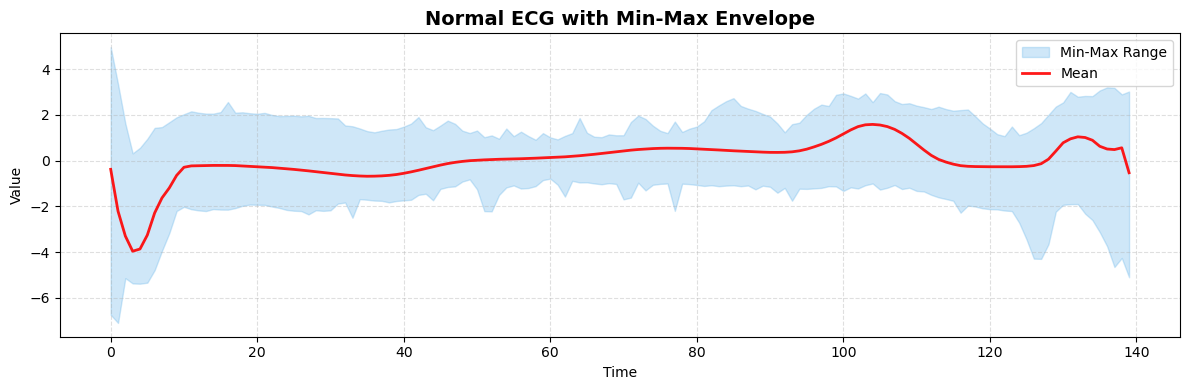

In [21]:
plot_mean_series_with_min_max_envelope(
    df=normal_df,
    time_cols=ts_columns,
    title="Normal ECG with Min-Max Envelope"
)

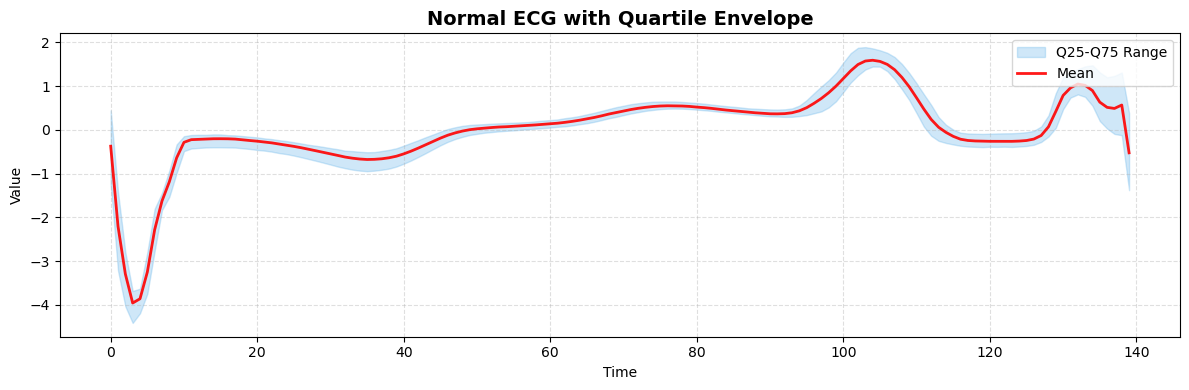

In [22]:
plot_mean_series_with_quartile_envelope(normal_df, ts_columns, 0.25, 0.75, 
                                        title="Normal ECG with Quartile Envelope")

#### LBBB time series

As shown below, when visualizing with min-max envelope, there is some outliers but, on the other hand, looking at the 50% central data (Q25 - Q75) it follows a concrete temporal pattern.

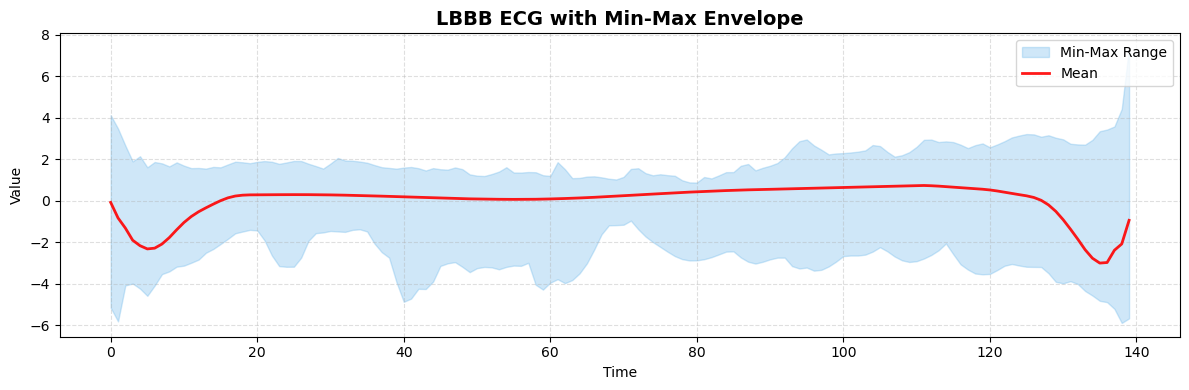

In [23]:
plot_mean_series_with_min_max_envelope(
    df=lbbb_df,
    time_cols=ts_columns,
    title="LBBB ECG with Min-Max Envelope"
)

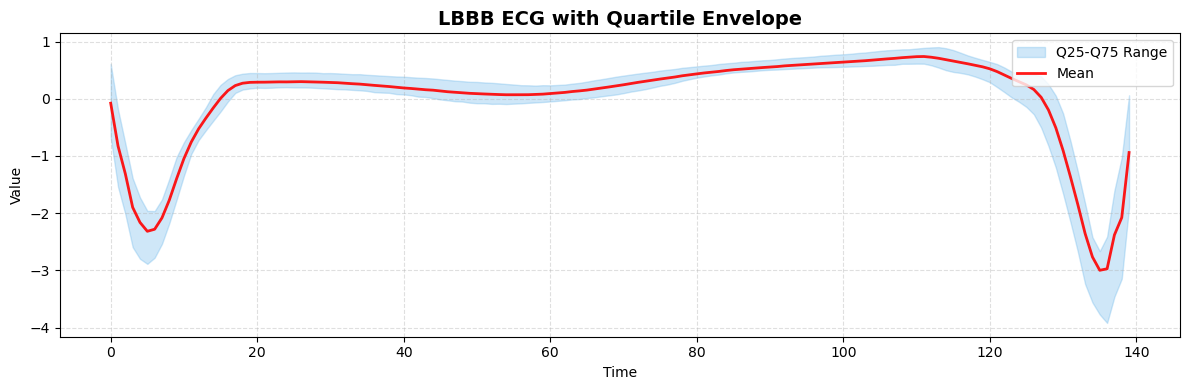

In [24]:
plot_mean_series_with_quartile_envelope(lbbb_df, ts_columns, 0.25, 0.75, 
                                        title="LBBB ECG with Quartile Envelope")

#### PVC time series

As shown below, when visualizing with min-max envelope, there is some outliers but, on the other hand, looking at the 50% central data (Q25 - Q75) it follows a concrete temporal pattern, **except for the last 20 data points, where it's shown a high variance.**

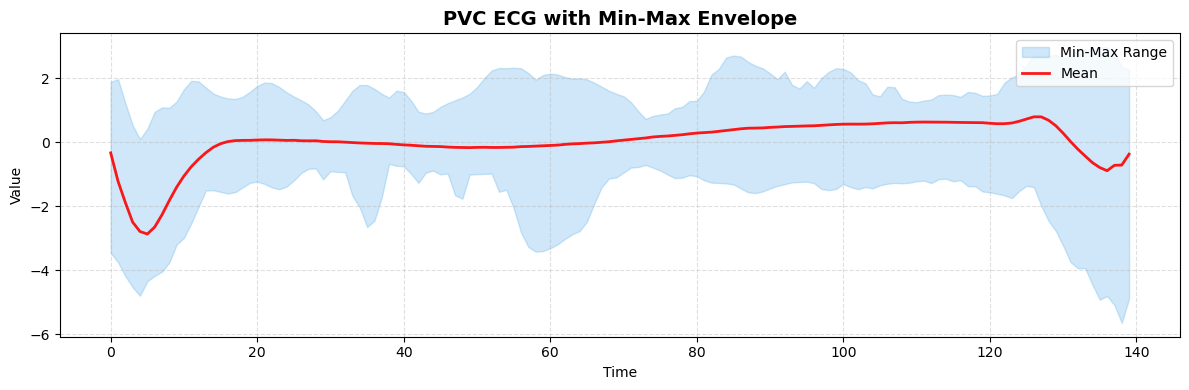

In [25]:
plot_mean_series_with_min_max_envelope(
    df=pvc_df,
    time_cols=ts_columns,
    title="PVC ECG with Min-Max Envelope"
)

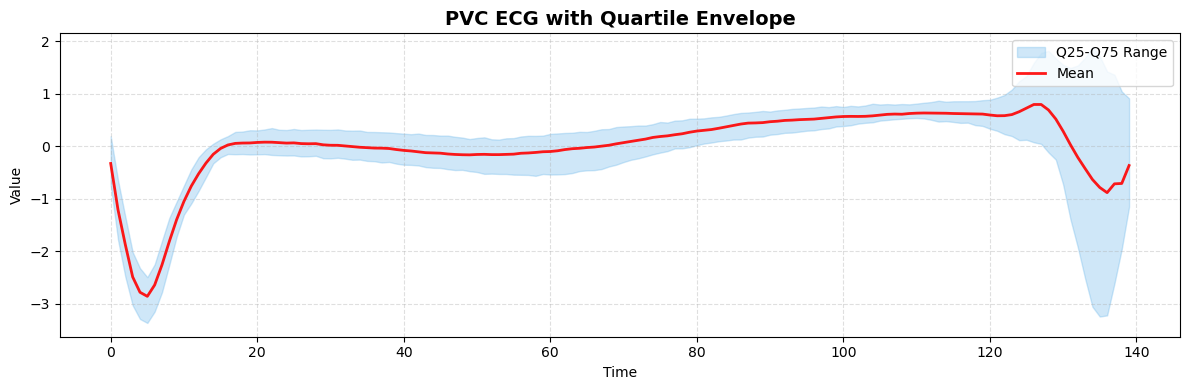

In [26]:
plot_mean_series_with_quartile_envelope(pvc_df, ts_columns, 0.25, 0.75, 
                                        title="PVC ECG with Quartile Envelope")

#### RBBB time series

As shown below, when visualizing with min-max envelope, there is some outliers but, on the other hand, looking at the 50% central data (Q25 - Q75) it follows a concrete temporal pattern.

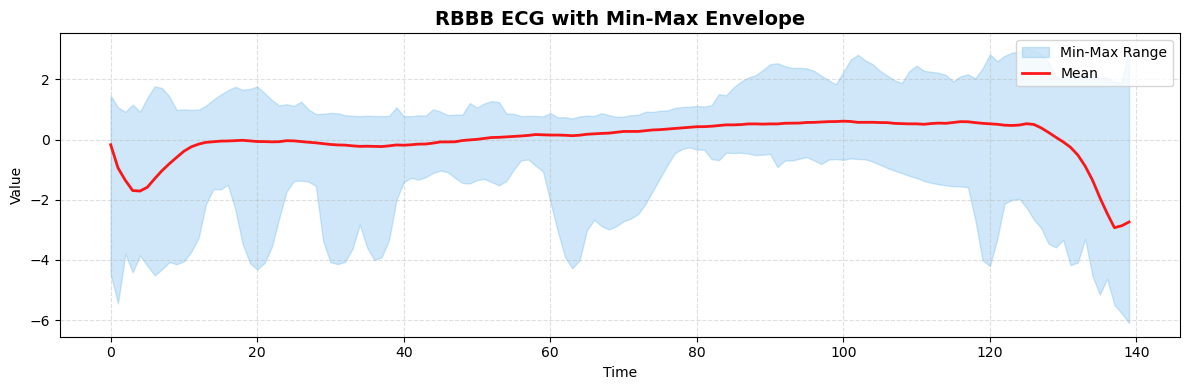

In [27]:
plot_mean_series_with_min_max_envelope(
    df=rbbb_df,
    time_cols=ts_columns,
    title="RBBB ECG with Min-Max Envelope"
)

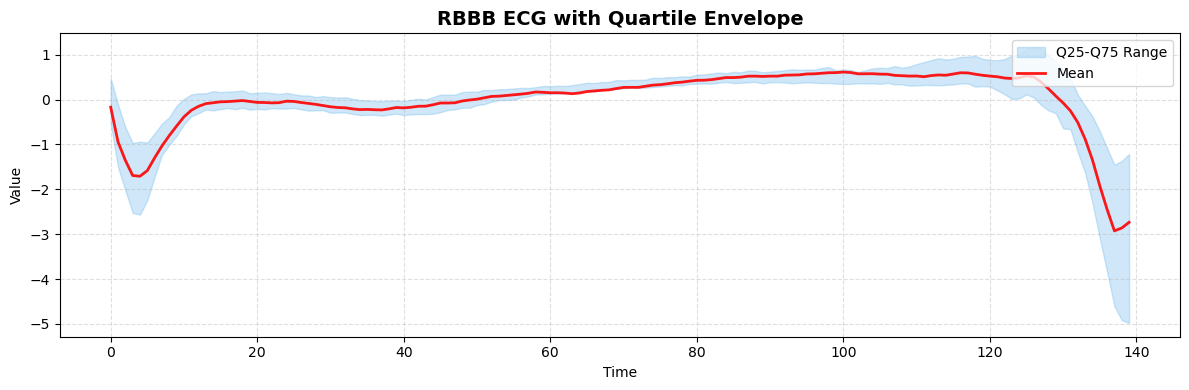

In [28]:
plot_mean_series_with_quartile_envelope(rbbb_df, ts_columns, 0.25, 0.75, 
                                        title="RBBB ECG with Quartile Envelope")

#### PB time series

As shown below, when visualizing with min-max envelope, there is some outliers but, on the other hand, looking at the 50% central data (Q25 - Q75) it follows a concrete temporal pattern, **except for the first and last 10 data points, where it's shown a high variance.**

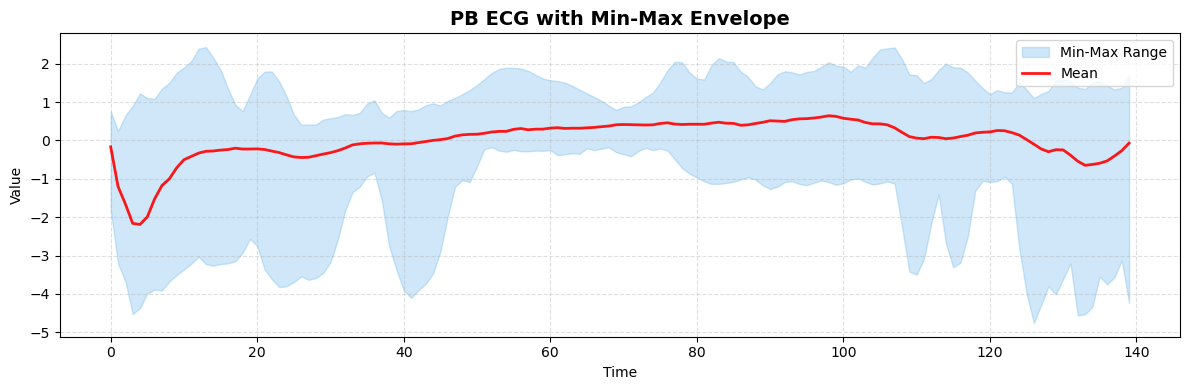

In [29]:
plot_mean_series_with_min_max_envelope(
    df=pb_df,
    time_cols=ts_columns,
    title="PB ECG with Min-Max Envelope"
)

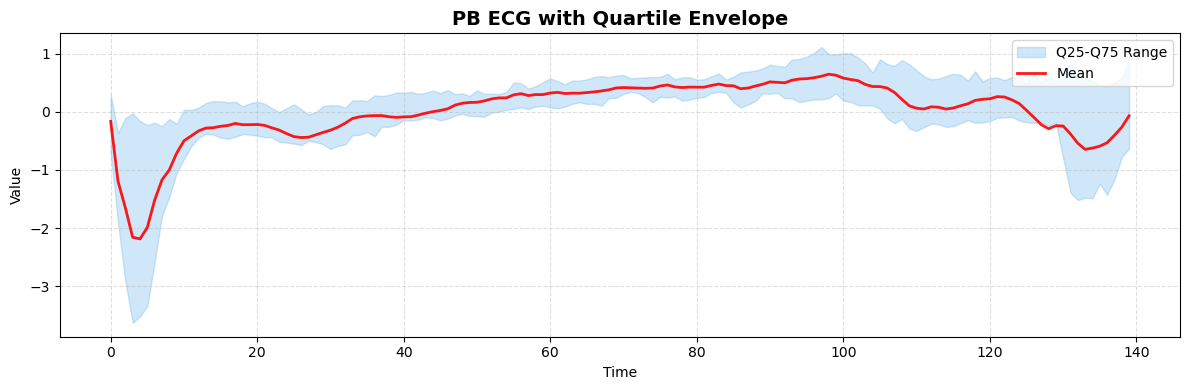

In [30]:
plot_mean_series_with_quartile_envelope(pb_df, ts_columns, 0.25, 0.75, 
                                        title="PB ECG with Quartile Envelope")

### Normal X Anomaly classes

In this section, the mean of normal time series will be compared to the mean time series of each anomaly classes.

In [31]:
normal_idx = df.query('detailedTarget == "Normal"').index.to_list()
lbbb_idx = df.query('detailedTarget == "LBBB"').index.to_list()
pvc_idx = df.query('detailedTarget == "PVC"').index.to_list()
rbbb_idx = df.query('detailedTarget == "RBBB"').index.to_list()
pb_idx = df.query('detailedTarget == "PB"').index.to_list()

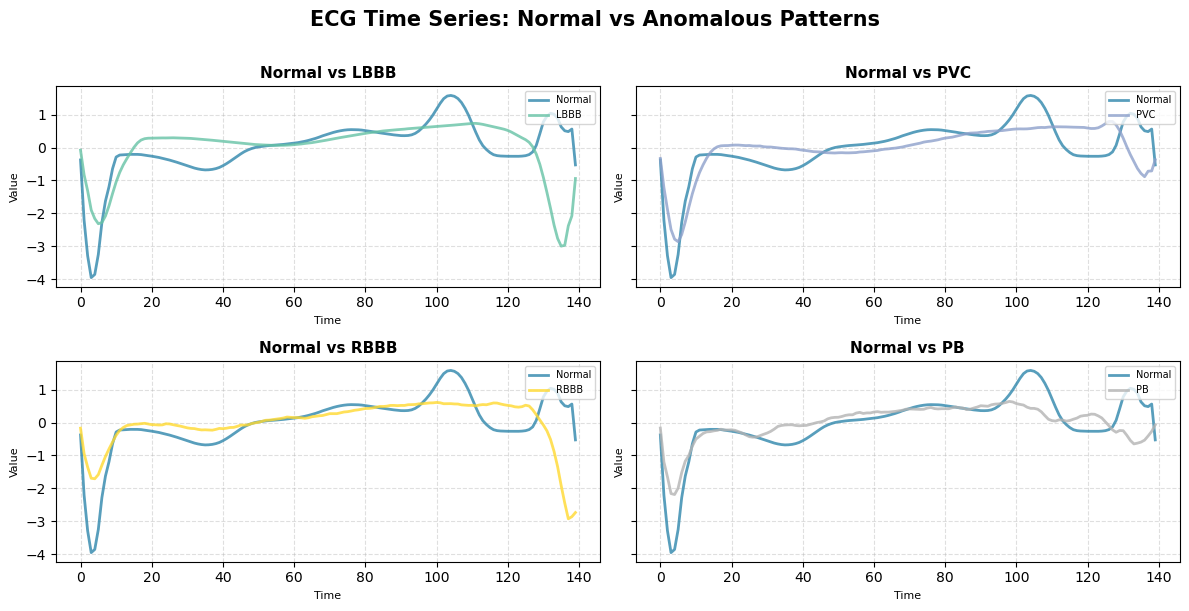

In [34]:
plot_mean_comparison_grid(
    df=df,
    time_cols=ts_columns,
    base_idx=normal_idx,
    compare_idx=[lbbb_idx, pvc_idx, rbbb_idx, pb_idx],
    titles=["Normal vs LBBB", "Normal vs PVC", "Normal vs RBBB", "Normal vs PB"],
    base_label="Normal",
    compare_labels=["LBBB", "PVC", "RBBB", "PB"],
    main_title="ECG Time Series: Normal vs Anomalous Patterns"
)

The anomalous series differ from normal mainly at the beginning and end of the ECG signal, while the middle region (approximately time 20-100) remains relatively consistent across all classes.